# Step 1: JSON Parsing

In [1]:
import json
import os

# Define relative paths (assuming the notebook is inside the 'notebooks' folder)
annotation_path = "../data/annotations/A_01.json"
video_path = "../data/raw_videos/A_01.mp4"

# 1. Load the JSON annotation file
with open(annotation_path, 'r') as file:
    annotation_data = json.load(file)

# 2. Parse the segments to find the stable chord (ignore 'N' for noise)
valid_segment = None
chord_label = None

for segment in annotation_data.get('segments', []):
    if segment['label'] != 'N':
        valid_segment = segment
        chord_label = segment['label']
        break  # We stop at the first valid chord for this exploration

# 3. Calculate the safest timestamp to extract the frame (the exact midpoint)
if valid_segment:
    start_time = valid_segment['start']
    end_time = valid_segment['end']
    
    # Midpoint calculation
    target_time_sec = start_time + (end_time - start_time) / 2.0
    
    print("--- JSON Parsing Successful ---")
    print(f"Video File  : {annotation_data['video']}")
    print(f"Chord Label : {chord_label}")
    print(f"Time Range  : {start_time}s to {end_time}s")
    print(f"Target Time : {target_time_sec:.3f}s (Safe midpoint for extraction)")
else:
    print("Error: No valid chord segment found in the JSON file.")

--- JSON Parsing Successful ---
Video File  : A_01.mp4
Chord Label : A
Time Range  : 4.31s to 8.11s
Target Time : 6.210s (Safe midpoint for extraction)


# Step 2: Targeted Frame Extraction

--- Frame Extracted Successfully at 6.210s ---


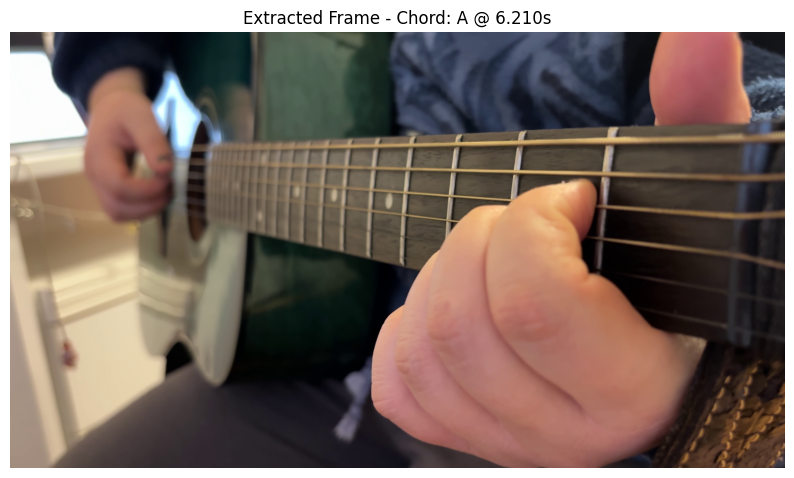

In [2]:
import cv2
import matplotlib.pyplot as plt

# 1. Initialize the video capture object
cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print(f"Error: Could not open video at {video_path}")
else:
    # 2. Set the video position to the exact target time (in milliseconds)
    target_time_ms = target_time_sec * 1000.0
    cap.set(cv2.CAP_PROP_POS_MSEC, target_time_ms)
    
    # 3. Read the frame at that specific timestamp
    success, frame = cap.read()
    
    if success:
        print(f"--- Frame Extracted Successfully at {target_time_sec:.3f}s ---")
        
        # Note: OpenCV loads images in BGR color format. 
        # Matplotlib expects RGB format. We must convert it before displaying.
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        
        # 4. Display the extracted frame
        plt.figure(figsize=(10, 6))
        plt.imshow(frame_rgb)
        plt.title(f"Extracted Frame - Chord: {chord_label} @ {target_time_sec:.3f}s")
        plt.axis('off') # Hide the axes for a cleaner look
        plt.show()
    else:
        print(f"Error: Could not read the frame at {target_time_sec:.3f}s")
    
    # 5. Always release the video file to free up system memory
    cap.release()

# Step 3: Visual Pre-processing (with equalizeHist) [YES FOR NOW]

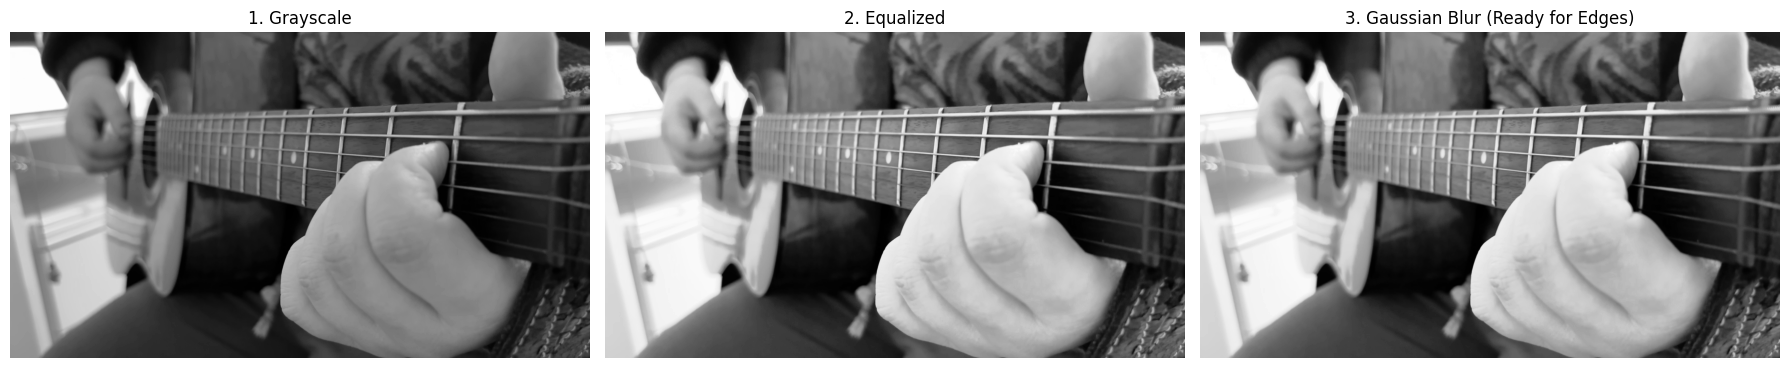

In [21]:
# 1. Convert the original BGR frame to Grayscale
gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

# 2. Apply Histogram Equalization to improve contrast and lighting
equalized_frame = cv2.equalizeHist(gray_frame)

# 3. Apply Gaussian Blur to reduce high-frequency noise (like wood grain)
# The (5, 5) tuple represents the kernel size (must be odd numbers).
blurred_frame = cv2.GaussianBlur(equalized_frame, (5, 5), 0)

# 4. Display the processing steps side-by-side for comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(gray_frame, cmap='gray')
axes[0].set_title('1. Grayscale')
axes[0].axis('off')

axes[1].imshow(equalized_frame, cmap='gray')
axes[1].set_title('2. Equalized')
axes[1].axis('off')

axes[2].imshow(blurred_frame, cmap='gray')
axes[2].set_title('3. Gaussian Blur (Ready for Edges)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

# Step 3: Visual Pre-processing (with CLAHE) [X]

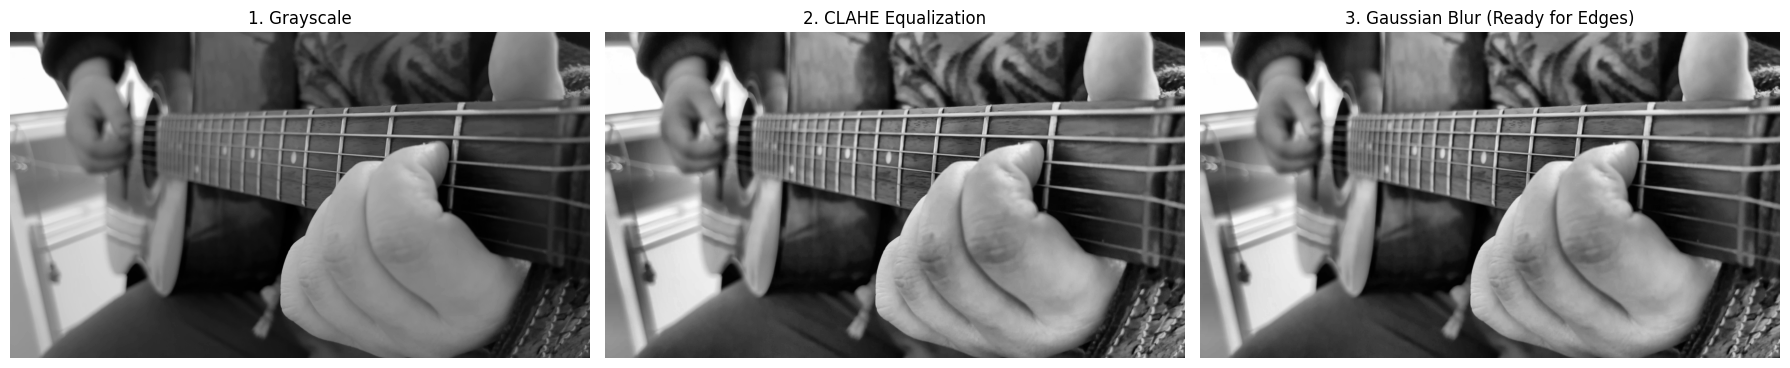

In [15]:
# 1. Convert the original BGR frame to Grayscale
gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

# 2. Inizializziamo e applichiamo il CLAHE (Contrast Limited Adaptive Histogram Equalization)
# clipLimit controlla il limite del contrasto (2.0 è lo standard), tileGridSize divide l'immagine in quadratini 8x8
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
equalized_frame = clahe.apply(gray_frame)

# 3. Apply Gaussian Blur to reduce high-frequency noise
blurred_frame = cv2.GaussianBlur(equalized_frame, (5, 5), 0)

# 4. Display the processing steps side-by-side for comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(gray_frame, cmap='gray')
axes[0].set_title('1. Grayscale')
axes[0].axis('off')

axes[1].imshow(equalized_frame, cmap='gray')
axes[1].set_title('2. CLAHE Equalization')
axes[1].axis('off')

axes[2].imshow(blurred_frame, cmap='gray')
axes[2].set_title('3. Gaussian Blur (Ready for Edges)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

# Step 4 - Canny Edge Detection (first attempt) [X]

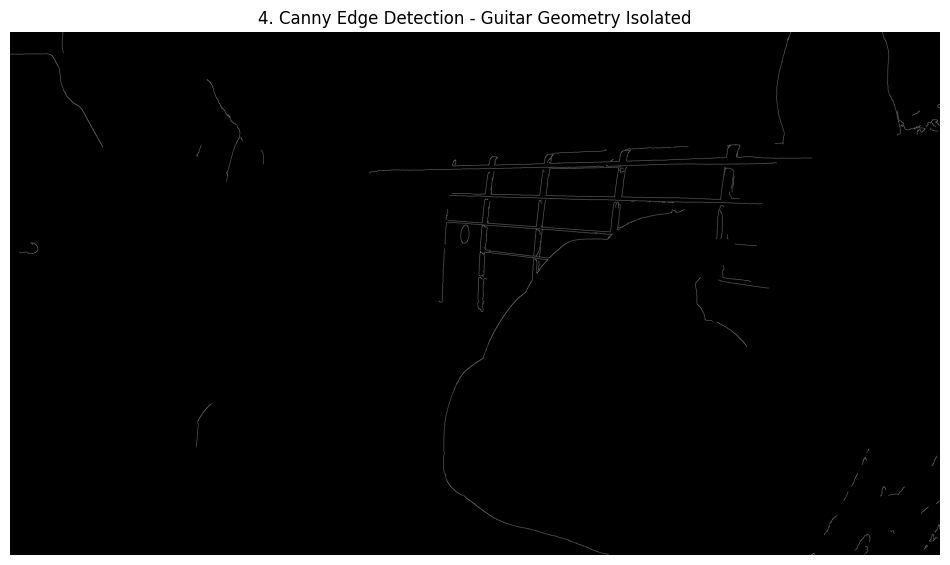

In [22]:
# 1. Apply Canny Edge Detection to the pre-processed frame
# The thresholds (lower=50, upper=150) are standard starting points.
# You can tweak these numbers if the strings are too faint or the noise is too high.
edges = cv2.Canny(blurred_frame, 50, 150)

# 2. Display the final "radiography" of our image
plt.figure(figsize=(12, 7))
plt.imshow(edges, cmap='gray')
plt.title('4. Canny Edge Detection - Guitar Geometry Isolated')
plt.axis('off')
plt.show()

# Step 4 - Canny Edge Detection (second attempt) [YES FOR NOW]

Testing Canny with thresholds: Lower=30, Upper=90


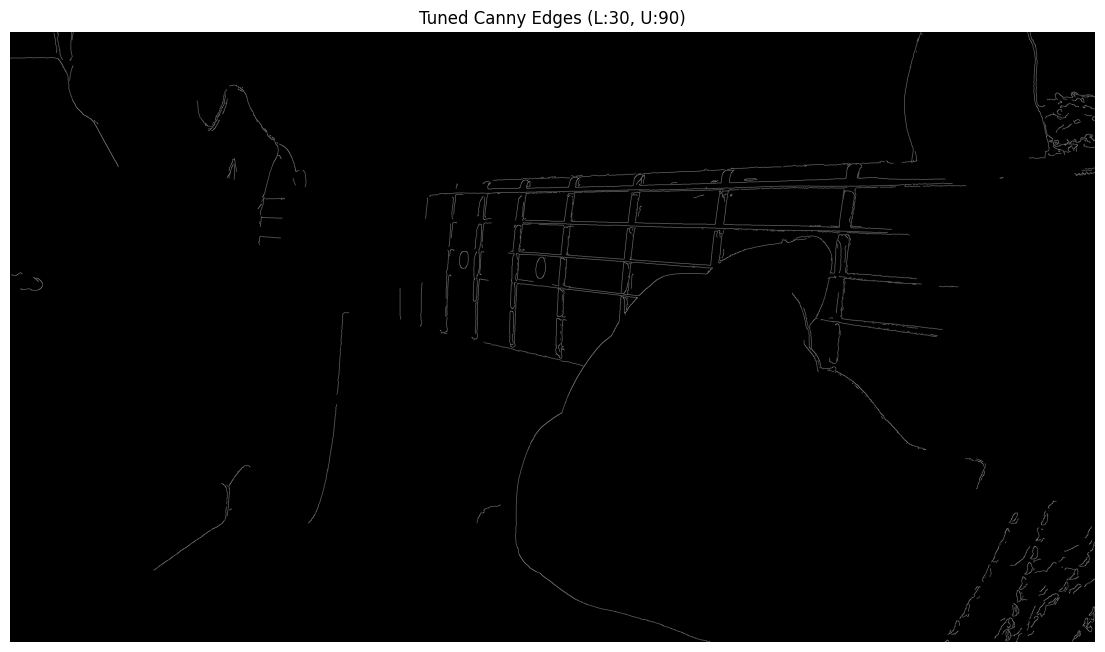

In [23]:
# ==========================================
# LAB: CANNY THRESHOLD TUNING
# ==========================================
# Change these two numbers to find the perfect balance!
# Rule of thumb: Lower numbers = more edges detected (but more noise).

CURRENT_LOWER_THRESH = 30  # Start with a low value (was 50)
CURRENT_UPPER_THRESH = 90  # Start lower than before (was 150)

print(f"Testing Canny with thresholds: Lower={CURRENT_LOWER_THRESH}, Upper={CURRENT_UPPER_THRESH}")

# 1. Apply Canny with the new experimental thresholds
tuned_edges = cv2.Canny(blurred_frame, CURRENT_LOWER_THRESH, CURRENT_UPPER_THRESH)

# 2. Display the result nicely
plt.figure(figsize=(14, 8))
plt.imshow(tuned_edges, cmap='gray')
plt.title(f'Tuned Canny Edges (L:{CURRENT_LOWER_THRESH}, U:{CURRENT_UPPER_THRESH})')
plt.axis('off')
plt.show()

# Auto Canny test [X]

L'algoritmo Auto Canny ha calcolato queste soglie: Lower=85, Upper=170


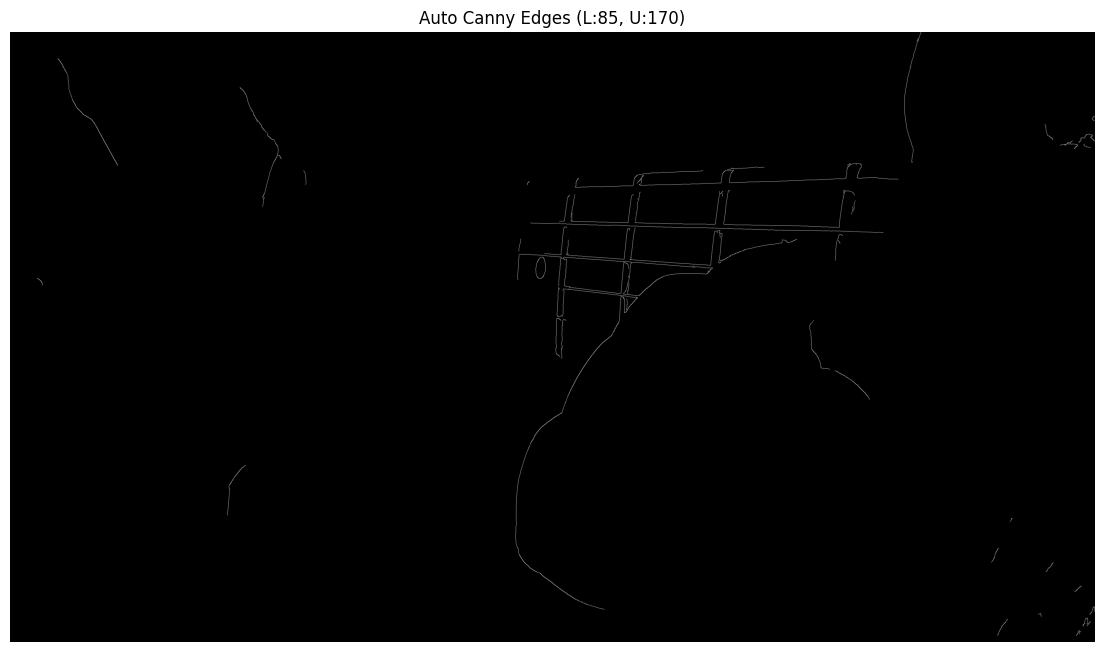

In [6]:
import numpy as np

def auto_canny(image, sigma=0.33):
    """
    Applica il Canny Edge Detection calcolando automaticamente le soglie
    basandosi sulla mediana dei pixel dell'immagine.
    """
    # 1. Calcola la mediana dei pixel
    v = np.median(image)
    
    # 2. Calcola le soglie inferiore e superiore
    lower = int(max(0, (1.0 - sigma) * v))
    upper = int(min(255, (1.0 + sigma) * v))
    
    # 3. Applica l'algoritmo Canny
    edged = cv2.Canny(image, lower, upper)
    
    return edged, lower, upper

# Eseguiamo la funzione sul nostro frame sfocato
auto_edges, calc_lower, calc_upper = auto_canny(blurred_frame)

print(f"L'algoritmo Auto Canny ha calcolato queste soglie: Lower={calc_lower}, Upper={calc_upper}")

# Visualizziamo il risultato
plt.figure(figsize=(14, 8))
plt.imshow(auto_edges, cmap='gray')
plt.title(f'Auto Canny Edges (L:{calc_lower}, U:{calc_upper})')
plt.axis('off')
plt.show()

# Trying Canny with different parameters [X]

Testing Canny with thresholds: Lower=60, Upper=120


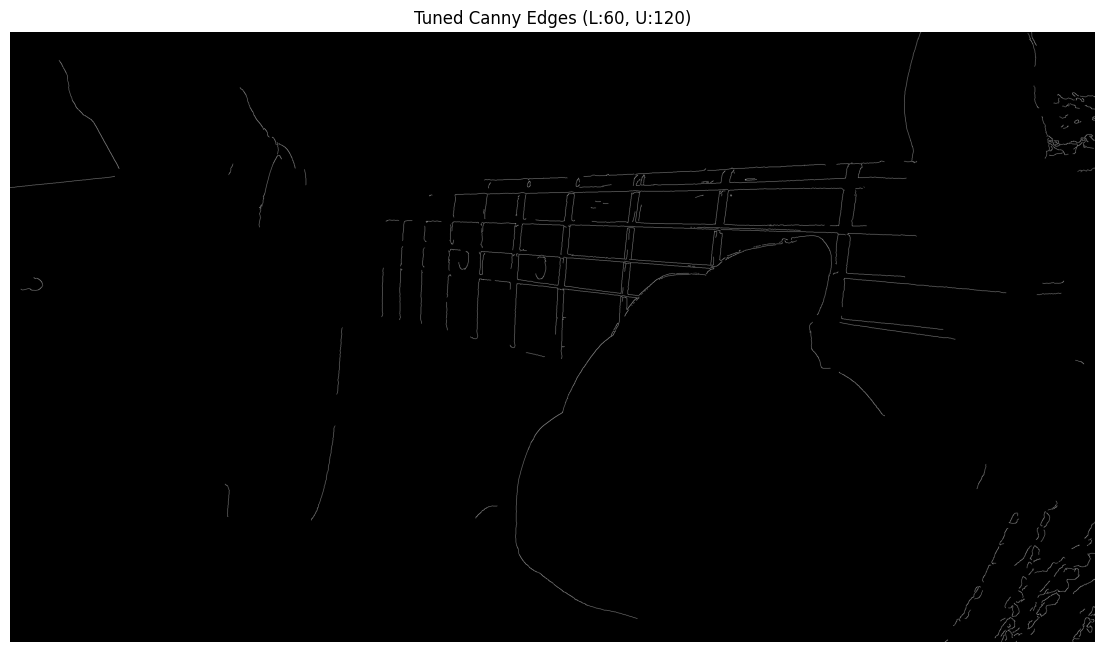

In [18]:
# ==========================================
# LAB: CANNY THRESHOLD TUNING
# ==========================================
# Change these two numbers to find the perfect balance!
# Rule of thumb: Lower numbers = more edges detected (but more noise).

CURRENT_LOWER_THRESH = 60  # Start with a low value (was 50)
CURRENT_UPPER_THRESH = 120  # Start lower than before (was 150)

print(f"Testing Canny with thresholds: Lower={CURRENT_LOWER_THRESH}, Upper={CURRENT_UPPER_THRESH}")

# 1. Apply Canny with the new experimental thresholds
tuned_edges = cv2.Canny(blurred_frame, CURRENT_LOWER_THRESH, CURRENT_UPPER_THRESH)

# 2. Display the result nicely
plt.figure(figsize=(14, 8))
plt.imshow(tuned_edges, cmap='gray')
plt.title(f'Tuned Canny Edges (L:{CURRENT_LOWER_THRESH}, U:{CURRENT_UPPER_THRESH})')
plt.axis('off')
plt.show()